# RNN Model 

## Data inspection and preparation

In [10]:
# imports
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import matplotlib
import itertools
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [21]:
# Load the .mat file
data = sio.loadmat('..\data\Xtrain.mat')
# Inspect the keys 
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Xtrain'])


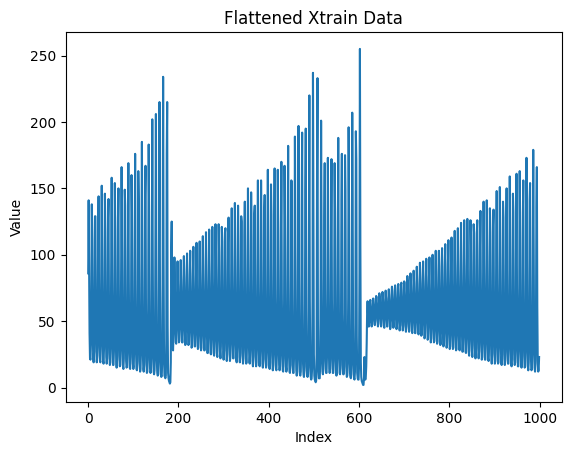

In [22]:
# plot flattened data
plt.plot(data['Xtrain'].flatten())
plt.title('Flattened Xtrain Data')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

In [23]:
# create extra datapoint by interpolation
extra_data = (data['Xtrain'][:-1] + data['Xtrain'][1:]) / 2
X_combined = np.empty((len(data['Xtrain']) + len(extra_data),), dtype=data['Xtrain'].dtype)
X_combined[0::2] = data['Xtrain'].flatten()
X_combined[1::2] = extra_data.flatten()
print("Total samples after interpolation:", len(X_combined))

Total samples after interpolation: 1999


In [25]:
# # plot extra data points
# plt.plot(X_combined)
# plt.title('Combined Xtrain Data with Interpolation')
# plt.xlabel('Index')
# plt.ylabel('Value')
# plt.show()

In [26]:
# reshape data
X_raw = data['Xtrain'].flatten()  # make 1D
print("Total samples:", len(X_raw))



Total samples: 1000


## Creating datasets

In [27]:
def create_dataset(X, time_steps=1):
    """
    Create sequences of data for RNN input.
    Args:
        X (array-like): The input data.
        time_steps (int): The number of time steps in each sequence.
    Returns:
        tuple: A tuple containing the sequences (Xs) and the corresponding targets (ys).
    """
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X[i:(i + time_steps)]
        Xs.append(v)
        ys.append(X[i + time_steps])
    return np.array(Xs), np.array(ys)

In [35]:
# build raw datasets without training test split
scaler = MinMaxScaler() # to train RNN with more stable
scaler.fit(X_raw.reshape(-1, 1))
X_scaled_raw = scaler.transform(X_raw.reshape(-1, 1)).flatten()
datasets_raw = {}
for i in [1, 2, 5, 10]:
    X_i, Y_i = create_dataset(X_scaled_raw, i)
    X_i = X_i.reshape(X_i.shape[0], X_i.shape[1], 1)
    
    datasets_raw[i] = {
        'X_train': X_i,
        'Y_train': Y_i, 
    }
    print(f"Window size {i}: train={X_i.shape}")

scaler.fit(X_combined.reshape(-1, 1))
X_scaled_combined = scaler.transform(X_combined.reshape(-1, 1)).flatten()

# Create datasets for each window size and store in dicts
datasets = {}

for i in [1, 2, 5, 10]:
    X_i, Y_i = create_dataset(X_scaled_combined, i)
    X_i = X_i.reshape(X_i.shape[0], X_i.shape[1], 1)
    datasets[i] = {
        'X_train': X_i, 
        'Y_train': Y_i, 
    }
    print(f"Window size {i}: train={X_i.shape}")


Window size 1: train=(999, 1, 1)
Window size 2: train=(998, 2, 1)
Window size 5: train=(995, 5, 1)
Window size 10: train=(990, 10, 1)
Window size 1: train=(1998, 1, 1)
Window size 2: train=(1997, 2, 1)
Window size 5: train=(1994, 5, 1)
Window size 10: train=(1989, 10, 1)


In [ ]:
# # Build raw datasets
# scaler = MinMaxScaler() # to train RNN with more stable
# scaler.fit(X_raw.reshape(-1, 1))
# X_scaled_raw = scaler.transform(X_raw.reshape(-1, 1)).flatten()

# datasets_raw = {}
# for i in [1, 2, 5, 10]:
#     X_i, Y_i = create_dataset(X_scaled_raw, i)
#     X_i = X_i.reshape(X_i.shape[0], X_i.shape[1], 1)
#     split = int(len(X_i) * 0.8)
#     datasets_raw[i] = {
#         'X_train': X_i[:split], 'X_test': X_i[split:],
#         'Y_train': Y_i[:split], 'Y_test': Y_i[split:],
#     }
#     print(f"Window size {i}: train={X_i[:split].shape}, test={X_i[split:].shape}")

Window size 1: train=(799, 1, 1), test=(200, 1, 1)
Window size 2: train=(798, 2, 1), test=(200, 2, 1)
Window size 5: train=(796, 5, 1), test=(199, 5, 1)
Window size 10: train=(792, 10, 1), test=(198, 10, 1)


In [ ]:
# # interpolated dataset

# # Normalize data 
# # scaler = MinMaxScaler() # to train RNN with more stable
# scaler.fit(X_combined.reshape(-1, 1))
# X_scaled_combined = scaler.transform(X_combined.reshape(-1, 1)).flatten()

# # Create datasets for each window size and store in dicts
# datasets = {}


# for i in [1, 2, 5, 10]:
#     X_i, Y_i = create_dataset(X_scaled_combined, i)
#     X_i = X_i.reshape(X_i.shape[0], X_i.shape[1], 1)
#     split = int(len(X_i) * 0.8)
#     datasets[i] = {
#         'X_train': X_i[:split], 'X_test': X_i[split:],
#         'Y_train': Y_i[:split], 'Y_test': Y_i[split:],
#     }
#     print(f"Window size {i}: train={X_i[:split].shape}, test={X_i[split:].shape}")


Window size 1: train=(1598, 1, 1), test=(400, 1, 1)
Window size 2: train=(1597, 2, 1), test=(400, 2, 1)
Window size 5: train=(1595, 5, 1), test=(399, 5, 1)
Window size 10: train=(1591, 10, 1), test=(398, 10, 1)


## Grid Search for Optimal Hyperparameters

Search over `window_size`, `rnn_units`, `learning_rate`, and `batch_size` using the raw dataset.

In [38]:
param_grid = {
    'window_size':   [1, 2, 5, 10],
    'rnn_units':     [20, 50, 100],
    'learning_rate': [0.001, 0.01],
    'batch_size':    [32, 64],
}

gs_results_raw = []
gs_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

keys, values = zip(*param_grid.items())
total = 1
for v in values:
    total *= len(v)
print(f"\nRunning {total} combinations on raw data...\n")

for idx, combo in enumerate(itertools.product(*values), 1):
    params = dict(zip(keys, combo))
    ws = params['window_size']
    d = datasets_raw[ws]

    model = Sequential([
        tf.keras.Input(shape=(ws, 1)),
        SimpleRNN(params['rnn_units'], activation='tanh'),
        Dense(1),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=params['learning_rate']),
        loss='mse',
        metrics=['mae'],
    )
    hist = model.fit(
        d['X_train'], d['Y_train'],
        epochs=100, batch_size=params['batch_size'], verbose=0,
        validation_split=0.2,
        # validation_data=(d['X_test'], d['Y_test']),
        callbacks=[gs_early_stop],
    )
    val_loss = min(hist.history['val_loss'])
    val_mae  = min(hist.history['val_mae'])
    gs_results_raw.append({
        **params,
        'val_loss':   val_loss,
        'val_mae':    val_mae,
        'epochs_run': len(hist.history['val_loss']),
    })
    print(f"[{idx:>2}/{total}] ws={ws}, units={params['rnn_units']:>3}, "
          f"lr={params['learning_rate']}, bs={params['batch_size']:>2} "
          f"-> val_loss={val_loss:.4f}, val_mae={val_mae:.4f}")

gs_df_raw = pd.DataFrame(gs_results_raw).sort_values('val_loss').reset_index(drop=True)
print("\nTop 10 configurations (raw):")
print(gs_df_raw.head(10).to_string(index=False))


Running 48 combinations on raw data...

[ 1/48] ws=1, units= 20, lr=0.001, bs=32 -> val_loss=0.0215, val_mae=0.1196
[ 2/48] ws=1, units= 20, lr=0.001, bs=64 -> val_loss=0.0259, val_mae=0.1366
[ 3/48] ws=1, units= 20, lr=0.01, bs=32 -> val_loss=0.0215, val_mae=0.1208
[ 4/48] ws=1, units= 20, lr=0.01, bs=64 -> val_loss=0.0216, val_mae=0.1187
[ 5/48] ws=1, units= 50, lr=0.001, bs=32 -> val_loss=0.0216, val_mae=0.1179
[ 6/48] ws=1, units= 50, lr=0.001, bs=64 -> val_loss=0.0216, val_mae=0.1201
[ 7/48] ws=1, units= 50, lr=0.01, bs=32 -> val_loss=0.0216, val_mae=0.1154
[ 8/48] ws=1, units= 50, lr=0.01, bs=64 -> val_loss=0.0216, val_mae=0.1153
[ 9/48] ws=1, units=100, lr=0.001, bs=32 -> val_loss=0.0216, val_mae=0.1176
[10/48] ws=1, units=100, lr=0.001, bs=64 -> val_loss=0.0216, val_mae=0.1191
[11/48] ws=1, units=100, lr=0.01, bs=32 -> val_loss=0.0217, val_mae=0.1171
[12/48] ws=1, units=100, lr=0.01, bs=64 -> val_loss=0.0217, val_mae=0.1147
[13/48] ws=2, units= 20, lr=0.001, bs=32 -> val_loss=

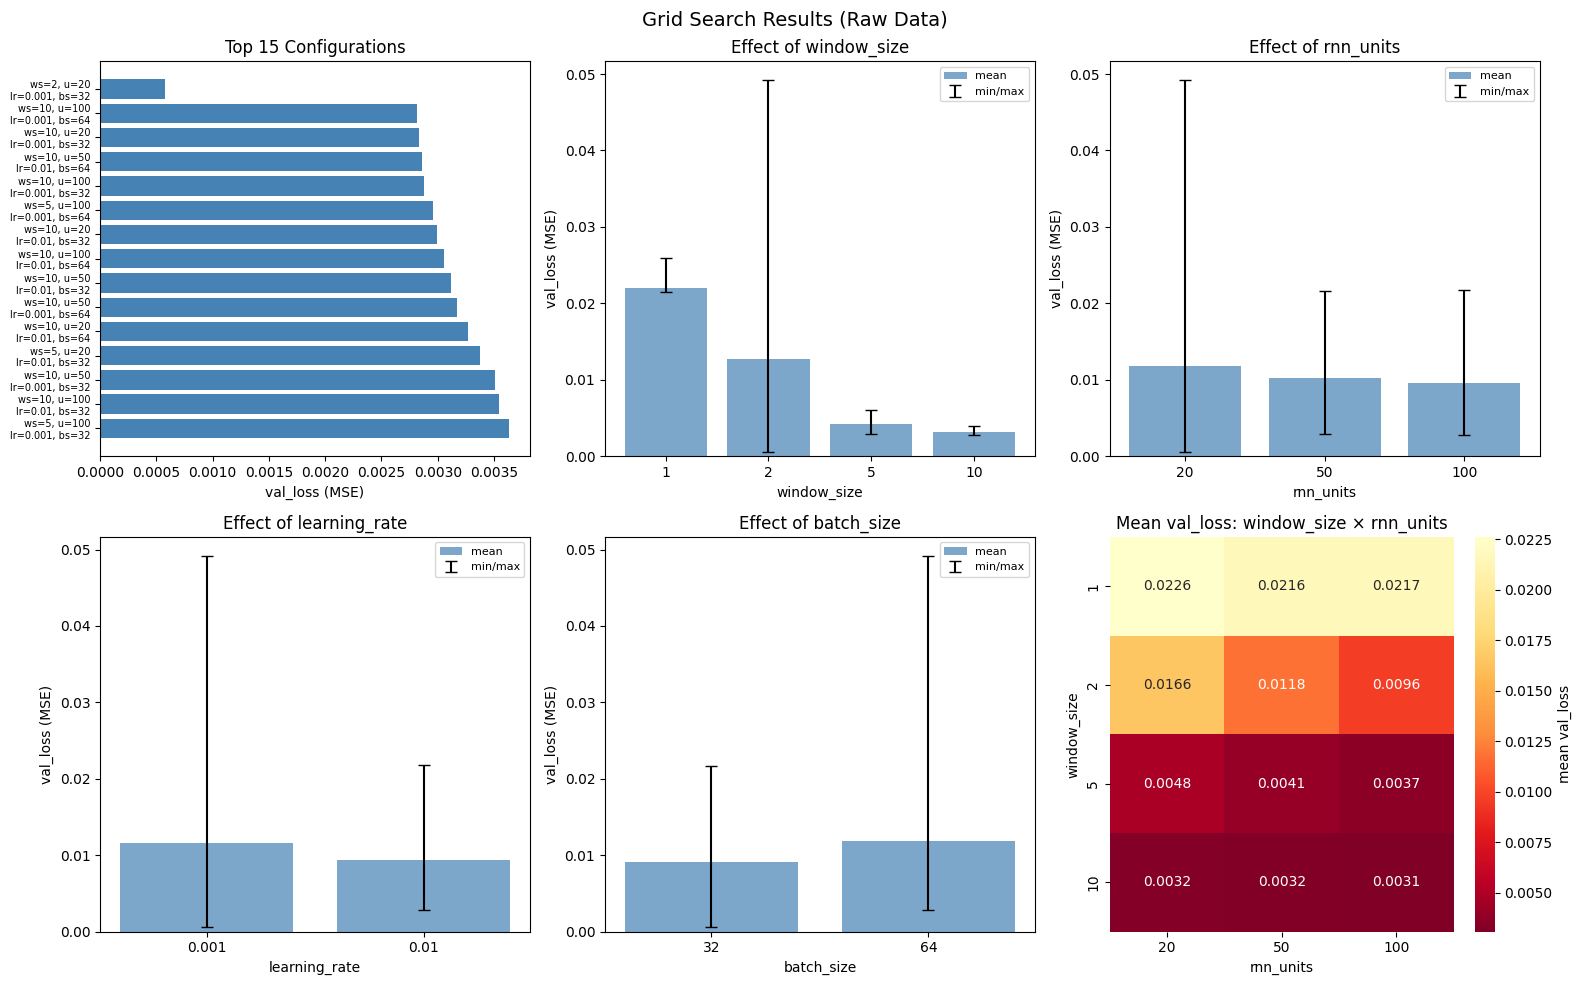


Best config: window_size=2, rnn_units=20, lr=0.001, batch_size=32
  val_loss=0.0006, val_mae=0.0184


In [39]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Grid Search Results (Raw Data)', fontsize=14)

# 1. Top 15 configs ranked by val_loss
ax = axes[0, 0]
top15 = gs_df_raw.head(15).copy()
labels = [f"ws={r.window_size}, u={r.rnn_units}\nlr={r.learning_rate}, bs={r.batch_size}"
          for r in top15.itertuples()]
ax.barh(range(len(top15)), top15['val_loss'], color='steelblue')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(labels, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('val_loss (MSE)')
ax.set_title('Top 15 Configurations')

# 2–5. Effect of each individual parameter on val_loss
for ax, param in zip(
    [axes[0, 1], axes[0, 2], axes[1, 0], axes[1, 1]],
    ['window_size', 'rnn_units', 'learning_rate', 'batch_size'],
):
    grouped = gs_df_raw.groupby(param)['val_loss'].agg(['mean', 'min', 'max']).reset_index()
    x = range(len(grouped))
    ax.bar(x, grouped['mean'], color='steelblue', alpha=0.7, label='mean')
    ax.errorbar(x, grouped['mean'],
                yerr=[grouped['mean'] - grouped['min'], grouped['max'] - grouped['mean']],
                fmt='none', color='black', capsize=4, label='min/max')
    ax.set_xticks(x)
    ax.set_xticklabels(grouped[param])
    ax.set_xlabel(param)
    ax.set_ylabel('val_loss (MSE)')
    ax.set_title(f'Effect of {param}')
    ax.legend(fontsize=8)

# 6. Heatmap: window_size × rnn_units (mean val_loss)
ax = axes[1, 2]
pivot = gs_df_raw.groupby(['window_size', 'rnn_units'])['val_loss'].mean().unstack()
sns.heatmap(pivot, ax=ax, annot=True, fmt='.4f', cmap='YlOrRd_r',
            cbar_kws={'label': 'mean val_loss'})
ax.set_title('Mean val_loss: window_size × rnn_units')
ax.set_xlabel('rnn_units')
ax.set_ylabel('window_size')

plt.tight_layout()
plt.show()

best = gs_df_raw.iloc[0]
print(f"\nBest config: window_size={int(best.window_size)}, rnn_units={int(best.rnn_units)}, "
      f"lr={best.learning_rate}, batch_size={int(best.batch_size)}")
print(f"  val_loss={best.val_loss:.4f}, val_mae={best.val_mae:.4f}")

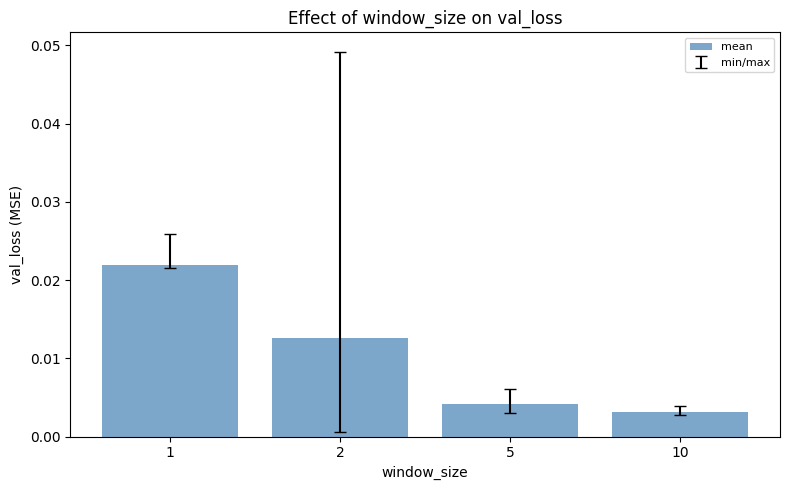

In [48]:
# only show effect of window size plot
fig, ax = plt.subplots(figsize=(8, 5))
grouped = gs_df_raw.groupby('window_size')['val_loss'].agg(['mean', 'min', 'max']).reset_index()
x = range(len(grouped))
ax.bar(x, grouped['mean'], color='steelblue', alpha=0.7, label='mean')
ax.errorbar(x, grouped['mean'],
            yerr=[grouped['mean'] - grouped['min'], grouped['max'] - grouped['mean']],
            fmt='none', color='black', capsize=4, label='min/max')
ax.set_xticks(x)
ax.set_xticklabels(grouped['window_size'])
ax.set_xlabel('window_size')
ax.set_ylabel('val_loss (MSE)')
ax.set_title('Effect of window_size on val_loss')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Final Model with Best Configuration

ws=2: units=20, lr=0.001, bs=32 -> stopped at epoch 172, best val_loss=0.00028909932007081807
ws=10: units=100, lr=0.001, bs=64 -> stopped at epoch 17, best val_loss=0.0023762411437928677


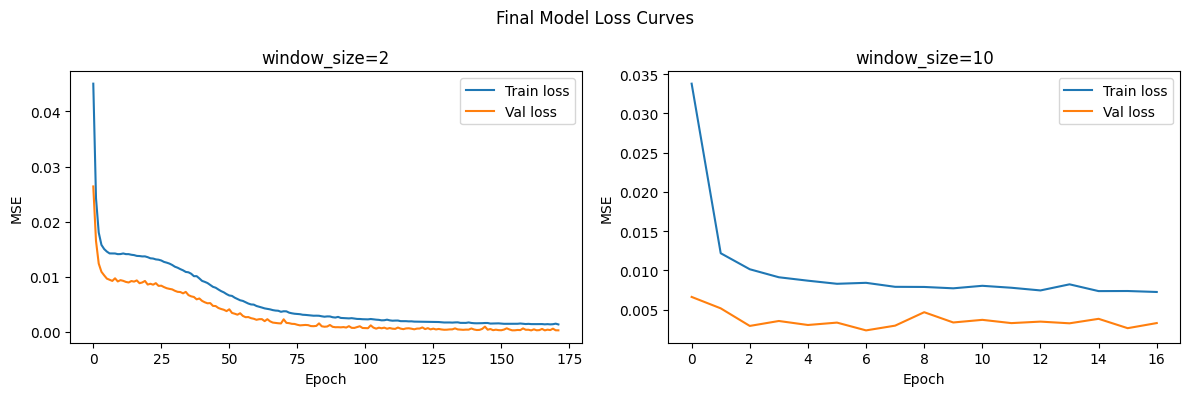

In [49]:
# Train one final model per window size using best config from grid search
final_models = {}
final_hists  = {}

for ws in [2, 10]:
    best = gs_df_raw[gs_df_raw['window_size'] == ws].sort_values('val_loss').iloc[0]
    d    = datasets_raw[ws]

    model = Sequential([
        tf.keras.Input(shape=(ws, 1)),
        SimpleRNN(int(best.rnn_units), activation='tanh'),
        Dense(1),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=best.learning_rate),
        loss='mse',
        metrics=['mae'],
    )
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
    hist = model.fit(
        d['X_train'], d['Y_train'],
        epochs=200, batch_size=int(best.batch_size),
        validation_split=0.2, verbose=0,
        callbacks=[early_stop],
    )
    final_models[ws] = model
    final_hists[ws]  = hist

    print(f"ws={ws}: units={int(best.rnn_units)}, lr={best.learning_rate}, "
          f"bs={int(best.batch_size)} -> stopped at epoch {len(hist.history['val_loss'])}, "
          f"best val_loss={min(hist.history['val_loss'])}")
    model.save(f'best_rnn_ws{ws}.keras')

# Loss curves side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Final Model Loss Curves', fontsize=12)
for ax, ws in zip(axes, [2, 10]):
    hist = final_hists[ws]
    ax.plot(hist.history['loss'],     label='Train loss')
    ax.plot(hist.history['val_loss'], label='Val loss')
    ax.set_title(f'window_size={ws}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
plt.tight_layout()
plt.show()

Test Set Evaluation Metrics
  MSE  : 25.8013
  RMSE : 5.0795
  MAE  : 4.2012
  MAPE : 10.36%
  R²   : 0.9870


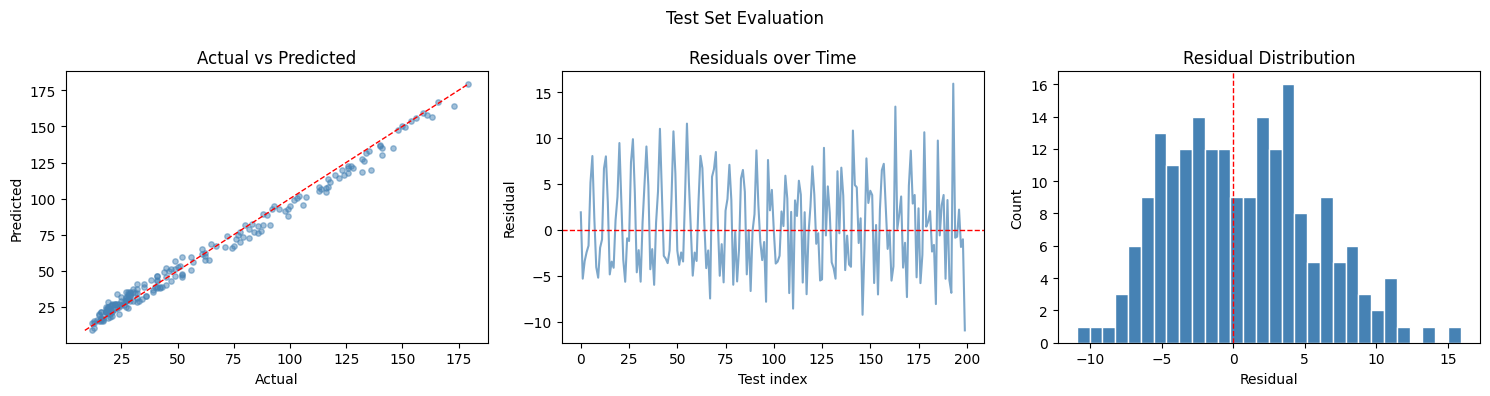

In [ ]:
# TODO test set evaluation and residual analysis for final models


# # Inverse-scaled test actuals and predictions
# y_true = scaler.inverse_transform(d['Y_test'].reshape(-1, 1)).flatten()
# y_pred = test_preds.flatten()

mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true))) * 100
r2   = r2_score(y_true, y_pred)

print("Test Set Evaluation Metrics")
print("=" * 35)
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  MAPE : {mape:.2f}%")
print(f"  R²   : {r2:.4f}")

# Residuals
residuals = y_true - y_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Test Set Evaluation', fontsize=12)

# Actual vs predicted scatter
axes[0].scatter(y_true, y_pred, alpha=0.5, s=15, color='steelblue')
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted')

# Residuals over time
axes[1].plot(residuals, color='steelblue', alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Test index')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals over Time')

# Residual distribution
axes[2].hist(residuals, bins=30, color='steelblue', edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

## Comparison: Raw vs Interpolated Data

Same grid search repeated on the interpolated 1999-point dataset. Results are compared against the raw grid search above.

In [46]:
# Grid search on interpolated data
gs_results = []
gs_early_stop_interp = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
print(f"Running {total} combinations on interpolated data...\n")

for idx, combo in enumerate(itertools.product(*values), 1):
    params = dict(zip(keys, combo))
    ws = params['window_size']
    d  = datasets[ws]

    model = Sequential([
        tf.keras.Input(shape=(ws, 1)),
        SimpleRNN(params['rnn_units'], activation='tanh'),
        Dense(1),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=params['learning_rate']),
        loss='mse',
        metrics=['mae'],
    )
    hist = model.fit(
        d['X_train'], d['Y_train'],
        epochs=100, batch_size=params['batch_size'], verbose=0,
        validation_split=0.2,
        callbacks=[gs_early_stop_interp],
    )
    val_loss = min(hist.history['val_loss'])
    val_mae  = min(hist.history['val_mae'])
    gs_results.append({
        **params,
        'val_loss':   val_loss,
        'val_mae':    val_mae,
        'epochs_run': len(hist.history['val_loss']),
    })
    print(f"[{idx:>2}/{total}] ws={ws}, units={params['rnn_units']:>3}, "
          f"lr={params['learning_rate']}, bs={params['batch_size']:>2} "
          f"-> val_loss={val_loss:.4f}, val_mae={val_mae:.4f}")

gs_df = pd.DataFrame(gs_results).sort_values('val_loss').reset_index(drop=True)
print("\nTop 10 configurations (interpolated):")
print(gs_df.head(10).to_string(index=False))

Running 48 combinations on interpolated data...

[ 1/48] ws=1, units= 20, lr=0.001, bs=32 -> val_loss=0.0188, val_mae=0.1013
[ 2/48] ws=1, units= 20, lr=0.001, bs=64 -> val_loss=0.0188, val_mae=0.1006
[ 3/48] ws=1, units= 20, lr=0.01, bs=32 -> val_loss=0.0186, val_mae=0.0943
[ 4/48] ws=1, units= 20, lr=0.01, bs=64 -> val_loss=0.0188, val_mae=0.1010
[ 5/48] ws=1, units= 50, lr=0.001, bs=32 -> val_loss=0.0188, val_mae=0.0969
[ 6/48] ws=1, units= 50, lr=0.001, bs=64 -> val_loss=0.0189, val_mae=0.1028
[ 7/48] ws=1, units= 50, lr=0.01, bs=32 -> val_loss=0.0191, val_mae=0.0950
[ 8/48] ws=1, units= 50, lr=0.01, bs=64 -> val_loss=0.0186, val_mae=0.0976
[ 9/48] ws=1, units=100, lr=0.001, bs=32 -> val_loss=0.0188, val_mae=0.1017
[10/48] ws=1, units=100, lr=0.001, bs=64 -> val_loss=0.0189, val_mae=0.1032
[11/48] ws=1, units=100, lr=0.01, bs=32 -> val_loss=0.0187, val_mae=0.0951
[12/48] ws=1, units=100, lr=0.01, bs=64 -> val_loss=0.0189, val_mae=0.0968
[13/48] ws=2, units= 20, lr=0.001, bs=32 -> v

                                  Interpolated              Raw
Best val_loss                           0.0056           0.0006
Best val_mae                            0.0417           0.0184
window_size                                  5                2
rnn_units                                   20               20
learning_rate                            0.001            0.001
batch_size                                  32               32


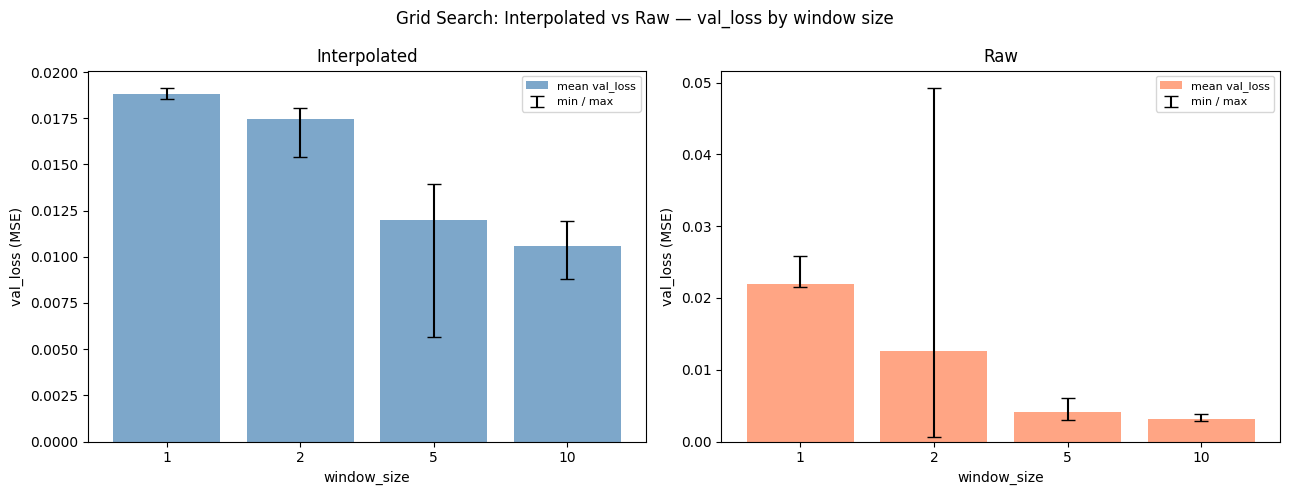

In [47]:
best_interp = gs_df.iloc[0]
best_raw    = gs_df_raw.iloc[0]

# Side-by-side summary table
print(f"{'':30} {'Interpolated':>15}  {'Raw':>15}")
print("=" * 65)
for label, vi, vr in [
    ('Best val_loss',    f"{best_interp.val_loss:.4f}",        f"{best_raw.val_loss:.4f}"),
    ('Best val_mae',     f"{best_interp.val_mae:.4f}",         f"{best_raw.val_mae:.4f}"),
    ('window_size',      str(int(best_interp.window_size)),    str(int(best_raw.window_size))),
    ('rnn_units',        str(int(best_interp.rnn_units)),      str(int(best_raw.rnn_units))),
    ('learning_rate',    str(best_interp.learning_rate),       str(best_raw.learning_rate)),
    ('batch_size',       str(int(best_interp.batch_size)),     str(int(best_raw.batch_size))),
]:
    print(f"{label:30} {vi:>15}  {vr:>15}")

# Visual comparison: val_loss distribution per window size
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Grid Search: Interpolated vs Raw — val_loss by window size', fontsize=12)

colors = ['steelblue', 'coral']
for ax, df, label, color in zip(
    axes, [gs_df, gs_df_raw], ['Interpolated', 'Raw'], colors
):
    grouped = df.groupby('window_size')['val_loss'].agg(['mean', 'min', 'max']).reset_index()
    x = range(len(grouped))
    ax.bar(x, grouped['mean'], color=color, alpha=0.7, label='mean val_loss')
    ax.errorbar(x, grouped['mean'],
                yerr=[grouped['mean'] - grouped['min'], grouped['max'] - grouped['mean']],
                fmt='none', color='black', capsize=5, label='min / max')
    ax.set_xticks(x)
    ax.set_xticklabels(grouped['window_size'])
    ax.set_xlabel('window_size')
    ax.set_ylabel('val_loss (MSE)')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### References

- https://medium.com/@rakesh.ganya28/building-sequential-models-with-rnn-recurrent-neural-networks-using-keras-api-d32a83d7b6b5